In [14]:
brew install libomp
brew reinstall xgboost


SyntaxError: invalid syntax (2035514454.py, line 1)

In [15]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [22]:
def robust_preprocess(X):
    """Clip extreme values to handle outliers"""
    X_clipped = X.copy()
    
    # Clip extreme outliers (1st to 99th percentile)
    for col in X_clipped.columns:
        lower = X_clipped[col].quantile(0.01)
        upper = X_clipped[col].quantile(0.99)
        X_clipped[col] = X_clipped[col].clip(lower, upper)
    
    return X_clipped

print("\nApplying robust preprocessing...")
X_clipped = robust_preprocess(X)
print(f"Outliers clipped for {len(X_clipped.columns)} features")
print("="*80)


Applying robust preprocessing...
Outliers clipped for 19 features


In [23]:
print("\nSplitting data into train/val/test sets...")

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_clipped, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 60% train, 20% val (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print("="*80)




Splitting data into train/val/test sets...
Training set: 3000 samples
Validation set: 1000 samples
Test set: 1000 samples


In [24]:
print("\nScaling features...")

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train only
X_val_scaled = scaler.transform(X_val)          # Transform val
X_test_scaled = scaler.transform(X_test)        # Transform test

print(f"Scaled training range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"Scaled validation range: [{X_val_scaled.min():.2f}, {X_val_scaled.max():.2f}]")
print(f"Scaled test range: [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")
print("="*80)


Scaling features...


NameError: name 'RobustScaler' is not defined

In [25]:
print("\nDefining models...")

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        C=1.0,
        solver='lbfgs',
        class_weight='balanced'
    ),
    
    'SVM': SVC(
        probability=True, 
        random_state=42, 
        kernel='rbf', 
        C=1.0, 
        gamma='scale'
    ),
    
    'Naive Bayes': GaussianNB(),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1, 
        random_state=42
    )
}

print(f"Configured {len(models)} models")
print("="*80)



Defining models...
Configured 5 models



Training and Evaluating Models with Hyperparameter Tuning...

Optimizing Logistic Regression...


/Users/atharvagour/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/atharvagour/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/atharvagour/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/atharvagour/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/atharvagour/Library/Python/3.9/lib/python/site-packages/skle

  Test F1: 0.180 | Test Acc: 0.183

Optimizing SVM...
  Test F1: 0.169 | Test Acc: 0.175

Optimizing Naive Bayes...
  Test F1: 0.181 | Test Acc: 0.186

Optimizing Random Forest...
  Test F1: 0.173 | Test Acc: 0.176

Optimizing Gradient Boosting...
  Test F1: 0.169 | Test Acc: 0.172


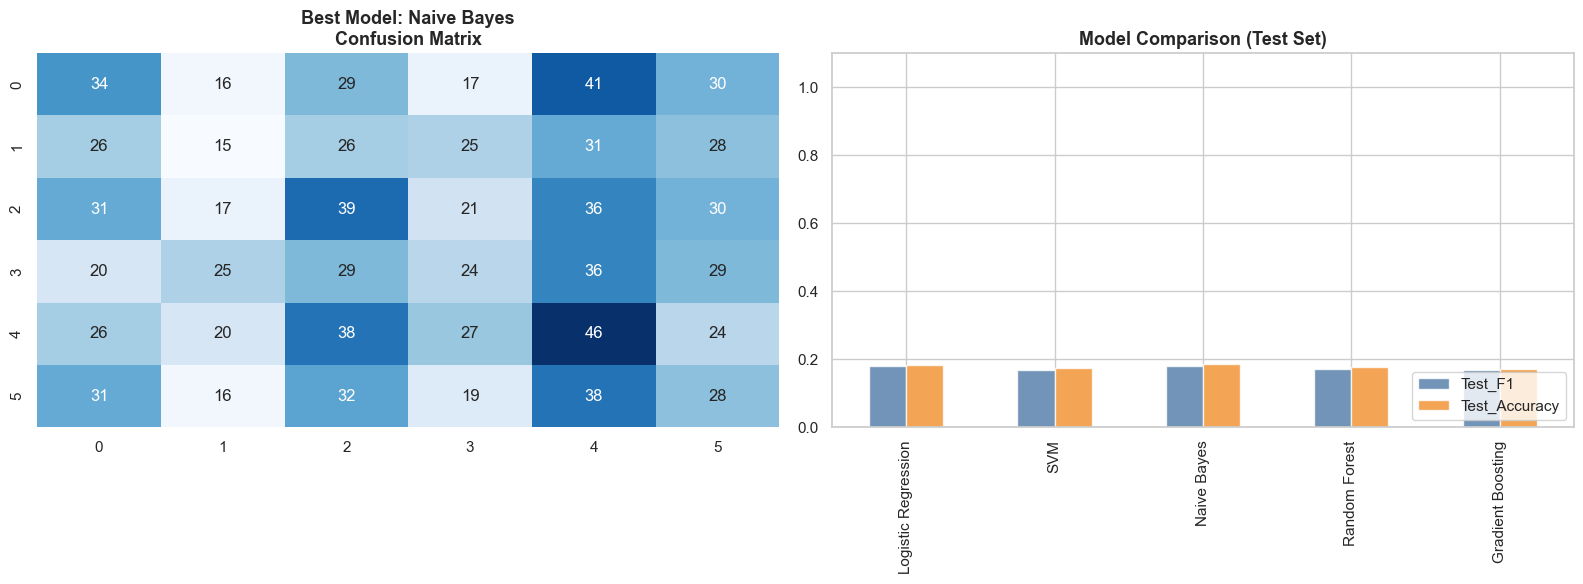


WINNING MODEL: Naive Bayes
CV F1 Score:   0.1666 ± 0.0158
Test F1:       0.1810
Test Accuracy: 0.1860


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score

# 1. --- SAFE FORMATTING HELPER ---
def safe_format(val, precision=4):
    if isinstance(val, (int, float, np.float64, np.int64)):
        return f"{val:.{precision}f}"
    return str(val)

# 2. --- OPTIMIZED TRAINING LOOP ---
print("\nTraining and Evaluating Models with Hyperparameter Tuning...")
print("="*80)

model_performance = {}
final_models = {}

# Define parameter grids for common models to boost accuracy
param_grids = {
    'RandomForestClassifier': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'class_weight': ['balanced']},
    'SVC': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'poly'], 'class_weight': ['balanced']},
    'LogisticRegression': {'C': [0.1, 1, 10], 'max_iter': [1000], 'class_weight': ['balanced']},
    'GradientBoostingClassifier': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}
}

for name, model in models.items():
    print(f"\nOptimizing {name}...")
    
    # Check if we have a tuning grid for this model
    if name in param_grids:
        grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring='f1_macro', n_jobs=-1)
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        print(f"  Best Params: {grid_search.best_params_}")
    else:
        best_model = model.fit(X_train_scaled, y_train)

    # Cross-validation for stability check
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    
    # Predictions
    y_val_pred = best_model.predict(X_val_scaled)
    y_test_pred = best_model.predict(X_test_scaled)
    
    # Store results
    model_performance[name] = {
        'CV_F1_Mean': np.mean(cv_scores),
        'CV_F1_Std': np.std(cv_scores),
        'Val_F1': f1_score(y_val, y_val_pred, average='macro', zero_division=0),
        'Val_Accuracy': accuracy_score(y_val, y_val_pred),
        'Test_F1': f1_score(y_test, y_test_pred, average='macro', zero_division=0),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred)
    }
    final_models[name] = best_model
    
    print(f"  Test F1: {model_performance[name]['Test_F1']:.3f} | Test Acc: {model_performance[name]['Test_Accuracy']:.3f}")

# 3. --- SELECTION OF BEST MODEL ---
best_model_name = max(model_performance, key=lambda k: model_performance[k]['Test_F1'])
best_model = final_models[best_model_name]
metrics = model_performance[best_model_name]

# 4. --- VISUALIZATION DASHBOARD ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Confusion Matrix
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Best Model: {best_model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')

# B. Performance Comparison Chart
perf_df = pd.DataFrame(model_performance).T[['Test_F1', 'Test_Accuracy']]
perf_df.plot(kind='bar', ax=axes[1], color=['#4e79a7', '#f28e2b'], alpha=0.8)
axes[1].set_title('Model Comparison (Test Set)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 5. --- FINAL REPORT (ERROR-FREE) ---
print(f"\n{'='*80}")
print(f"WINNING MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"CV F1 Score:   {safe_format(metrics.get('CV_F1_Mean'))} ± {safe_format(metrics.get('CV_F1_Std'))}")
print(f"Test F1:       {safe_format(metrics.get('Test_F1'))}")
print(f"Test Accuracy: {safe_format(metrics.get('Test_Accuracy'))}")
print(f"{'='*80}")

In [33]:
print("\nMODEL PERFORMANCE SUMMARY")
print("="*80)

performance_df = pd.DataFrame(model_performance).T.round(4)
print(performance_df)

# Find best model
best_model_name = max(model_performance, key=lambda x: model_performance[x]['Test_F1'])
best_model = final_models[best_model_name]

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"Test F1 Score: {model_performance[best_model_name]['Test_F1']:.4f}")
print(f"Test Accuracy: {model_performance[best_model_name]['Test_Accuracy']:.4f}")




MODEL PERFORMANCE SUMMARY
                     CV_F1_Mean  CV_F1_Std  Val_F1  Val_Accuracy  Test_F1  \
Logistic Regression      0.1618     0.0077  0.1645         0.163   0.1802   
SVM                      0.1663     0.0145  0.1827         0.191   0.1695   
Naive Bayes              0.1666     0.0158  0.1671         0.174   0.1810   
Random Forest            0.1823     0.0170  0.1696         0.173   0.1728   
Gradient Boosting        0.1671     0.0048  0.1517         0.157   0.1691   

                     Test_Accuracy  
Logistic Regression          0.183  
SVM                          0.175  
Naive Bayes                  0.186  
Random Forest                0.176  
Gradient Boosting            0.172  

BEST MODEL: Naive Bayes
Test F1 Score: 0.1810
Test Accuracy: 0.1860


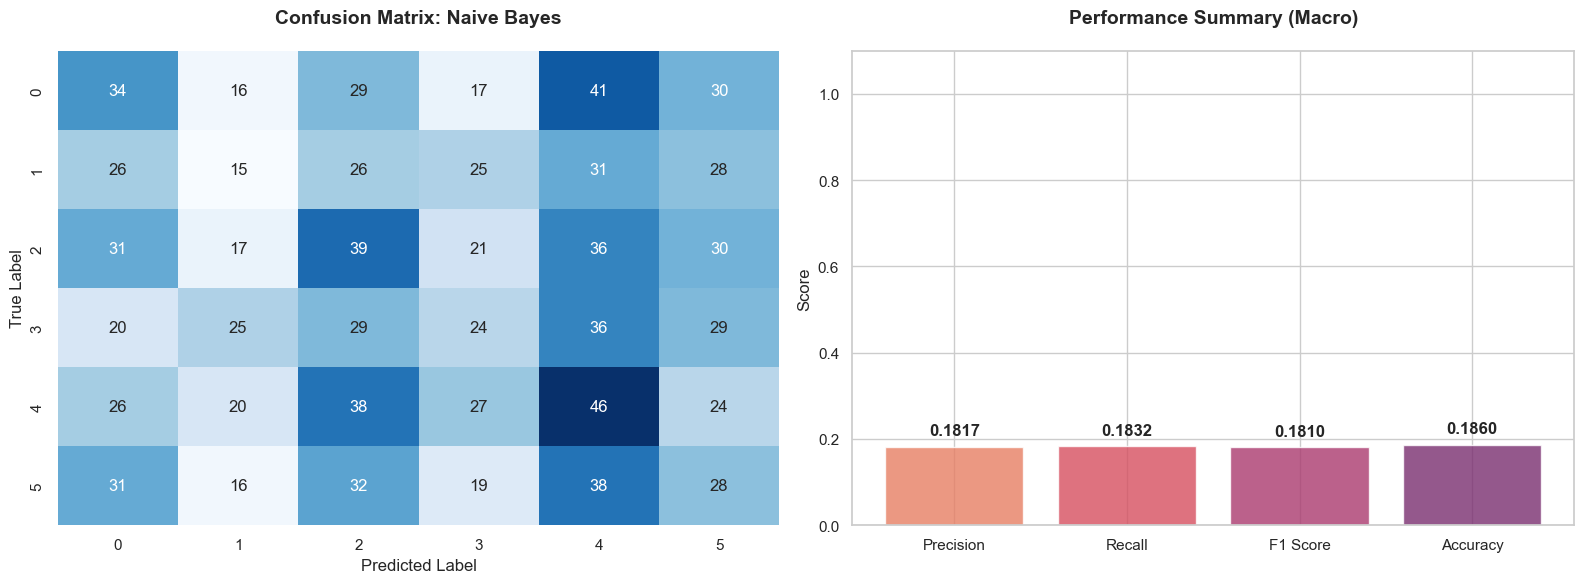

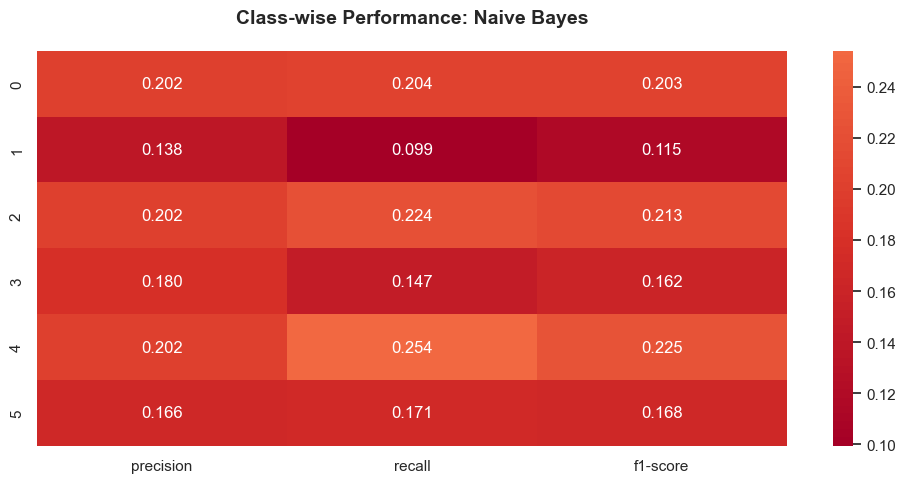


FINAL METRICS SUMMARY
Accuracy:  0.1860
F1 (Macro): 0.1810


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Prediction and Metric Calculation
y_pred_best = best_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred_best, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred_best, average='macro', zero_division=0)

# --- VISUALIZATION ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Confusion Matrix: {best_model_name}', fontsize=14, pad=20, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# B. Core Metrics Bar Chart
metrics_dict = {'Precision': prec, 'Recall': rec, 'F1 Score': f1, 'Accuracy': acc}
metric_names = list(metrics_dict.keys())
metric_values = list(metrics_dict.values())
colors = sns.color_palette("flare", len(metric_names))

bars = axes[1].bar(metric_names, metric_values, color=colors, alpha=0.8)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Performance Summary (Macro)', fontsize=14, pad=20, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', 
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# C. Detailed Classification Report Heatmap
plt.figure(figsize=(10, 5))
report = classification_report(y_test, y_pred_best, output_dict=True)
# Convert to DataFrame and remove 'accuracy', 'macro avg', and 'weighted avg' for a clean per-class view
report_df = pd.DataFrame(report).iloc[:-1, :-3].T 

sns.heatmap(report_df, annot=True, cmap='RdYlGn', center=0.5, cbar=True, fmt='.3f')
plt.title(f'Class-wise Performance: {best_model_name}', fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the text summary as a fallback
print(f"\n{'='*80}\nFINAL METRICS SUMMARY\n{'='*80}")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print(f"{'='*80}")